Import

In [2]:
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern

Load Saved Model

In [6]:
rf = joblib.load(
    "model1/random_forest_model.pkl"
)

encoder = joblib.load(
    "model1/label_encoder.pkl"
)

Copy feature extract function

In [7]:
def extract_features(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(
        img,
        (224,224)
    )

    hsv = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2HSV
    )

    hist = cv2.calcHist(
        [hsv],
        [0,1,2],
        None,
        [8,8,8],
        [0,256,0,256,0,256]
    )

    hist = cv2.normalize(
        hist,
        hist
    ).flatten()

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    lbp = local_binary_pattern(

        gray,

        8,

        1,

        method='uniform'

    )

    lbp_hist,_ = np.histogram(

        lbp.ravel(),

        bins=np.arange(11),

        range=(0,10)

    )

    lbp_hist = lbp_hist.astype(
        "float"
    )

    lbp_hist /= (

        lbp_hist.sum()+1e-6

    )

    features = np.hstack(

        [hist,lbp_hist]

    )

    return features

spoilage function

In [8]:
def calculate_spoilage(image_path):

    img = cv2.imread(
        image_path
    )

    hsv = cv2.cvtColor(

        img,

        cv2.COLOR_BGR2HSV

    )

    lower = np.array(
        [5,50,50]
    )

    upper = np.array(
        [30,255,255]
    )

    fruit_mask = cv2.inRange(

        hsv,

        lower,

        upper

    )

    gray = cv2.cvtColor(

        img,

        cv2.COLOR_BGR2GRAY

    )

    _, defect = cv2.threshold(

        gray,

        80,

        255,

        cv2.THRESH_BINARY_INV

    )

    defect_inside = cv2.bitwise_and(

        defect,

        fruit_mask

    )

    fruit_pixels = np.sum(
        fruit_mask>0
    )

    defect_pixels = np.sum(
        defect_inside>0
    )

    spoilage = (

        defect_pixels/

        fruit_pixels

    )*100

    return spoilage

In [15]:
image_path = "dataset/test/blackspot/b (5).jpg"

Prediction

In [16]:
features = extract_features(
    image_path
)

prediction = rf.predict(
    [features]
)

label = encoder.inverse_transform(
    prediction
)[0]

spoilage = calculate_spoilage(
    image_path
)

Final Output

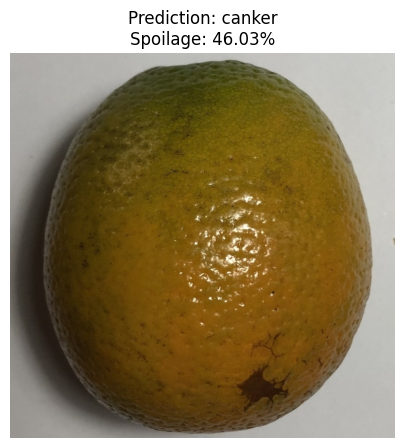

Predicted Defect: canker
Spoilage: 46.03%


In [17]:
img = cv2.imread(
    image_path
)

img = cv2.cvtColor(

    img,

    cv2.COLOR_BGR2RGB

)

plt.figure(
    figsize=(5,5)
)

plt.imshow(img)

plt.title(

f"Prediction: {label}\n"

f"Spoilage: {spoilage:.2f}%"

)

plt.axis('off')

plt.show()

print(
    "Predicted Defect:",
    label
)

print(
    f"Spoilage: {spoilage:.2f}%"
)